# From Point Cloud to Pattern Explanation

Full pipeline walkthrough:
```
3D point cloud -> preprocess -> landmarks -> BodyParams levels -> explain()
```
No real data scan needed — we generate a synthetic body cloud. To use a real scan replace `generate_body()` with `load_pointcloud('scan.ply')`.

**Run from** the repo root.

## Setup

In [1]:
import sys, os, importlib.util, pathlib

# Resolve repo root whether launched from repo root or notebooks/
repo_root = pathlib.Path(os.getcwd())
if not (repo_root / 'research').exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import Patch

print('Repo root:', repo_root)
print('NumPy:', np.__version__)

Repo root: /Users/ilonaeisenbraun/Documents/MobileNorm/body-pattern-research
NumPy: 2.4.3


## Step 1: Generate (or load) a point cloud

The synthetic generator builds ellipsoidal anatomical segment approximations.
It covers 7 profiles: `standard`, `wheelchair`, `prosthesis_left_lower`, `prosthesis_left_upper`,
`dwarfism_proportional`, `dwarfism_disproportional`, `plus_size`.

> **To use a real scan:**
> ```python
> from research.pointcloud.loader import load_pointcloud
> pts_raw = load_pointcloud('path/to/scan.ply')  # .ply .obj .npy .npz .xyz all supported
> ```

In [2]:
# IMPORTANT: register the module in sys.modules BEFORE exec_module.
# Without this, Python 3.13 raises:
#   AttributeError: 'NoneType' object has no attribute '__dict__'
# because @dataclass tries to resolve __module__ during class creation
# and finds None if the module hasn't been registered yet.
gen_path = repo_root / 'scripts' / 'generate_synthetic_body.py'
spec = importlib.util.spec_from_file_location('generate_synthetic_body', gen_path)
gen  = importlib.util.module_from_spec(spec)
sys.modules['generate_synthetic_body'] = gen   # <-- must come before exec_module
spec.loader.exec_module(gen)

# n_points is a field on SyntheticBodyConfig (default 4096), not a generate_body() argument
config  = gen.PROFILES['wheelchair']
pts_raw = gen.generate_body(config)

print(f'Profile:   {config.label}')
print(f'Height:    {config.height_m:.2f} m  |  Weight: {config.weight_kg} kg')
print(f'Raw cloud: {pts_raw.shape}  (N points x 3 xyz)')
print(f'Y range:   [{pts_raw[:,1].min():.3f}, {pts_raw[:,1].max():.3f}]  (height axis)')

Profile:   wheelchair
Height:    1.65 m  |  Weight: 70.0 kg
Raw cloud: (4096, 3)  (N points x 3 xyz)
Y range:   [-0.003, 1.082]  (height axis)


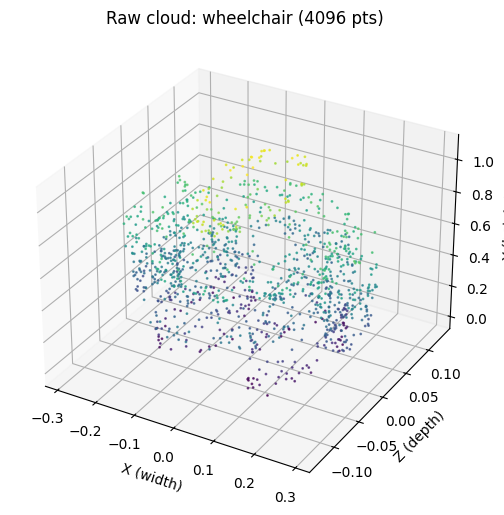

In [3]:
fig = plt.figure(figsize=(5, 8))
ax  = fig.add_subplot(111, projection='3d')
idx = np.random.choice(len(pts_raw), min(1200, len(pts_raw)), replace=False)
ax.scatter(pts_raw[idx,0], pts_raw[idx,2], pts_raw[idx,1],
           s=1, c=pts_raw[idx,1], cmap='viridis', alpha=0.7)
ax.set_xlabel('X (width)'); ax.set_ylabel('Z (depth)'); ax.set_zlabel('Y (height)')
ax.set_title(f'Raw cloud: {config.label} ({len(pts_raw)} pts)')
plt.tight_layout(); plt.show()

## Step 2: Preprocess

Four steps controlled via `PreprocessConfig`:

| Step | What it does | Source |
|---|---|---|
| SOR outlier filter | Removes points far from k-NN neighbourhood | PCL (Rusu & Cousins 2011) |
| Downsample | Random uniform sample to exactly `n_points` | PointNet convention |
| Normalise | Centre at origin, scale to unit sphere | PointNet (4.1) |
| PCA align | Rotate so Y = height, X = width | Standard practice |

See `docs/ALGORITHMS.md` for the full mathematical description.

In [4]:
from research.pointcloud.preprocess import PreprocessPipeline, PreprocessConfig

# PreprocessPipeline takes a PreprocessConfig, not keyword arguments directly
cfg      = PreprocessConfig(n_points=2048, center=True, scale_to_unit=True, align=True)
pipeline = PreprocessPipeline(cfg)

pts_clean, info = pipeline(pts_raw)

print(f'{pts_raw.shape}  ->  {pts_clean.shape}')
print('Coordinate ranges after normalisation (unit sphere -> all in [-1, 1]):')
for i, label in enumerate('XYZ'):
    print(f'  {label}: [{pts_clean[:,i].min():.3f}, {pts_clean[:,i].max():.3f}]')
print('Pipeline info:', info)

(4096, 3)  ->  (2048, 3)
Coordinate ranges after normalisation (unit sphere -> all in [-1, 1]):
  X: [-0.571, 0.431]
  Y: [-0.284, 0.270]
  Z: [-0.123, 0.120]
Pipeline info: {'n_raw': 4096, 'n_after_outlier': 3963, 'n_after_voxel': 3875, 'offset': array([3.6986690e-05, 4.6240148e-01, 4.8317231e-04], dtype=float32), 'scale': np.float32(1.0832675), 'n_final': 2048}


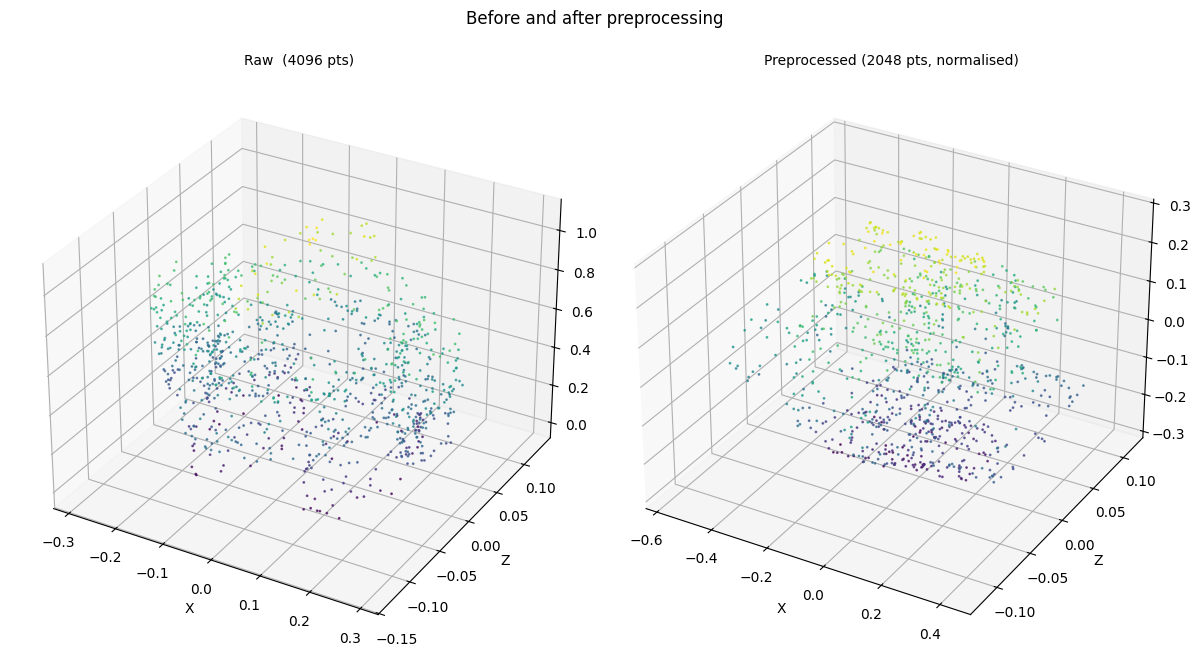

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 7), subplot_kw={'projection': '3d'})
for ax, pts, title in [
    (axes[0], pts_raw[:1000],   f'Raw  ({len(pts_raw)} pts)'),
    (axes[1], pts_clean[:1000], f'Preprocessed ({len(pts_clean)} pts, normalised)'),
]:
    ax.scatter(pts[:,0], pts[:,2], pts[:,1], s=1, c=pts[:,1], cmap='viridis', alpha=0.7)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('X'); ax.set_ylabel('Z'); ax.set_zlabel('Y')
plt.suptitle('Before and after preprocessing')
plt.tight_layout(); plt.show()

## Step 3: Heuristic landmark extraction

`LandmarkDetector` uses **geometric rules on XYZ coordinates** — no neural network at this stage.

The key idea: after canonical alignment (Y = height), different Y-percentile bands correspond
to anatomical regions. We extract widths from those bands:

| Landmark | Y-band | How extracted |
|---|---|---|
| Shoulder width | top 15% | X-extent of points |
| Hip width | 40–60% | X-extent of points |
| Upper arm (L/R) | 70–80% | X-extent per side (x<0 / x>0) |
| Height | full cloud | Y.max - Y.min |
| Inseam | bottom 50% | Y-extent of lower region |

See `docs/ALGORITHMS.md` for the full derivation and known limitations.

In [6]:
from research.pointcloud.landmarks import LandmarkDetector
import dataclasses

# LandmarkDetector works on normalised coordinates.
# from_landmarks() applies height_m scaling to convert to mm.
detector  = LandmarkDetector()
landmarks = detector.detect(pts_clean)

print('Landmark values (normalised unit-sphere coordinates):')
for f in dataclasses.fields(landmarks):
    val = getattr(landmarks, f.name)
    if isinstance(val, float):
        print(f'  {f.name:30s}  {val:.4f}')

print(f'\nAsymmetry (0 = symmetric):')
print(f'  arm: {landmarks.asymmetry_arm():.4f}')
print(f'  leg: {landmarks.asymmetry_leg():.4f}')

Landmark values (normalised unit-sphere coordinates):
  shoulder_width_norm             0.7212
  hip_width_norm                  0.9702
  waist_width_norm                0.9740
  left_arm_length_norm            0.2782
  right_arm_length_norm           0.2726
  left_leg_length_norm            0.3173
  right_leg_length_norm           0.2837
  torso_height_norm               0.1305
  seated_rise_norm                0.0000

Asymmetry (0 = symmetric):
  arm: 0.0203
  leg: 0.1184


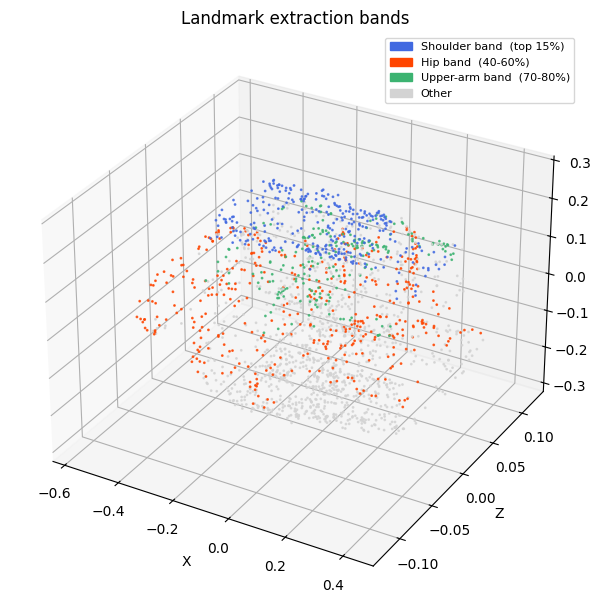

In [7]:
# Show which points feed which measurement band
fig = plt.figure(figsize=(6, 9))
ax  = fig.add_subplot(111, projection='3d')
y   = pts_clean[:,1]
colors = np.full(len(pts_clean), 'lightgray', dtype=object)
colors[y > np.percentile(y, 85)]                                 = 'royalblue'
colors[(y > np.percentile(y, 40)) & (y < np.percentile(y, 60))] = 'orangered'
colors[(y > np.percentile(y, 70)) & (y < np.percentile(y, 80))] = 'mediumseagreen'
ax.scatter(pts_clean[:,0], pts_clean[:,2], pts_clean[:,1],
           s=1, c=list(colors), alpha=0.8)
ax.legend(handles=[
    Patch(color='royalblue',      label='Shoulder band  (top 15%)'),
    Patch(color='orangered',      label='Hip band  (40-60%)'),
    Patch(color='mediumseagreen', label='Upper-arm band  (70-80%)'),
    Patch(color='lightgray',      label='Other'),
], fontsize=8, loc='upper right')
ax.set_title('Landmark extraction bands')
ax.set_xlabel('X'); ax.set_ylabel('Z'); ax.set_zlabel('Y')
plt.tight_layout(); plt.show()

## Step 4: Map to BodyParams levels + explain()

`ScanToParams.from_landmarks()` converts each landmark value to a discrete **Level 0–4**
by comparing against population thresholds (DIN EN 13402 / disability literature).

```
value < t1  ->  Level.NONE   (within normal range)
value < t2  ->  Level.LOW
value < t3  ->  Level.MID
value < t4  ->  Level.HIGH
else        ->  Level.MAX
```

The `explain()` method then tells you *why* each axis got the level it did.

In [8]:
from research.mapping.scan_to_params import ScanToParams, _USING_ADJUSTER

print(f'Using diverse-body-pattern-adjuster BodyParams: {_USING_ADJUSTER}')
print('(False = standalone stub, no adjuster install required)\n')

mapper = ScanToParams()
params = mapper.from_landmarks(landmarks, height_m=config.height_m)

print('BodyParams levels:')
for ax_name in [
    'height_level','shoulder_width_level','bust_level','hip_level',
    'inseam_level','thigh_level','upper_arm_level',
    'left_upper_arm_step','right_upper_arm_step',
    'left_leg_step','right_leg_step',
    'seated_back_rise','forward_tilt_level',
]:
    v = getattr(params, ax_name)
    print(f'  {ax_name:30s}  {v.name:4s} ({v.value})')

Using diverse-body-pattern-adjuster BodyParams: False
(False = standalone stub, no adjuster install required)

BodyParams levels:
  height_level                    NONE (0)
  shoulder_width_level            MAX  (4)
  bust_level                      NONE (0)
  hip_level                       MAX  (4)
  inseam_level                    NONE (0)
  thigh_level                     NONE (0)
  upper_arm_level                 NONE (0)
  left_upper_arm_step             NONE (0)
  right_upper_arm_step            NONE (0)
  left_leg_step                   NONE (0)
  right_leg_step                  MOD  (2)
  seated_back_rise                NONE (0)
  forward_tilt_level              NONE (0)


In [9]:
# explain() shows which threshold was crossed for each axis
print(mapper.explain(landmarks, params))

── Scan → BodyParams Mapping Explanation ──
  shoulder_width (norm=0.721)  →  shoulder_width_level = 4
  hip_width      (norm=0.970)  →  hip_level = 4
  arm_asymmetry  (Δ=0.020)  →  left_arm=0  right_arm=0
  leg_asymmetry  (Δ=0.118)  →  left_leg=0  right_leg=2
  height_level   = 0
  inseam_level   = 0
  weight_level   = 4


## Step 5: Connect to the pattern adjuster

The `BodyParams` object passes directly into `diverse-body-pattern-adjuster`.
The adjuster has its own `explain()` that shows the *resulting mm delta per seam axis*.

```bash
pip install -e ../diverse-body-pattern-adjuster
```

In [10]:
try:
    from diverse_body_pattern_adjuster.pattern.adjustment import PatternAdjuster
    from diverse_body_pattern_adjuster.pattern.export import export_svg

    adjuster = PatternAdjuster()
    result   = adjuster.adjust(params)

    print('=== Pattern adjuster explain() ===')
    print(adjuster.explain(params))
    print(f'Total axes modified: {len(result.deltas)}')

    out_svg = repo_root / 'notebooks' / 'output_pattern.svg'
    export_svg(result, out_svg)
    print(f'SVG -> {out_svg}')

except ImportError:
    print('diverse-body-pattern-adjuster not installed.')
    print('Install: pip install -e ../diverse-body-pattern-adjuster')
    print('\nBodyParams is ready to pass in when you do:')
    print(params)

diverse-body-pattern-adjuster not installed.
Install: pip install -e ../diverse-body-pattern-adjuster

BodyParams is ready to pass in when you do:
BodyParams(weight_level=4, shoulder_width_level=4, hip_level=4, right_leg_step=2)


## Step 6: Compare all disability profiles

In [11]:
results = {}
for profile_name, profile_config in gen.PROFILES.items():
    pts      = gen.generate_body(profile_config)
    pts_c, _ = PreprocessPipeline(PreprocessConfig(n_points=2048))(pts)
    lm       = LandmarkDetector().detect(pts_c)
    p        = ScanToParams().from_landmarks(lm, height_m=profile_config.height_m)
    results[profile_name] = p
    print(f'{profile_name:35s}  hip={p.hip_level.name:4s}  '
          f'shoulder={p.shoulder_width_level.name:4s}  '
          f'back_rise={p.seated_back_rise.name:4s}  '
          f'arm_L={p.left_upper_arm_step.name}')

standard                             hip=MAX   shoulder=MAX   back_rise=NONE  arm_L=MILD
wheelchair                           hip=MAX   shoulder=MAX   back_rise=NONE  arm_L=NONE
prosthesis_left_lower                hip=MAX   shoulder=MAX   back_rise=NONE  arm_L=NONE
prosthesis_left_upper                hip=MAX   shoulder=MAX   back_rise=NONE  arm_L=NONE
dwarfism_proportional                hip=MAX   shoulder=MAX   back_rise=NONE  arm_L=MILD
dwarfism_disproportional             hip=MAX   shoulder=MAX   back_rise=NONE  arm_L=NONE
plus_size                            hip=MAX   shoulder=MAX   back_rise=NONE  arm_L=NONE


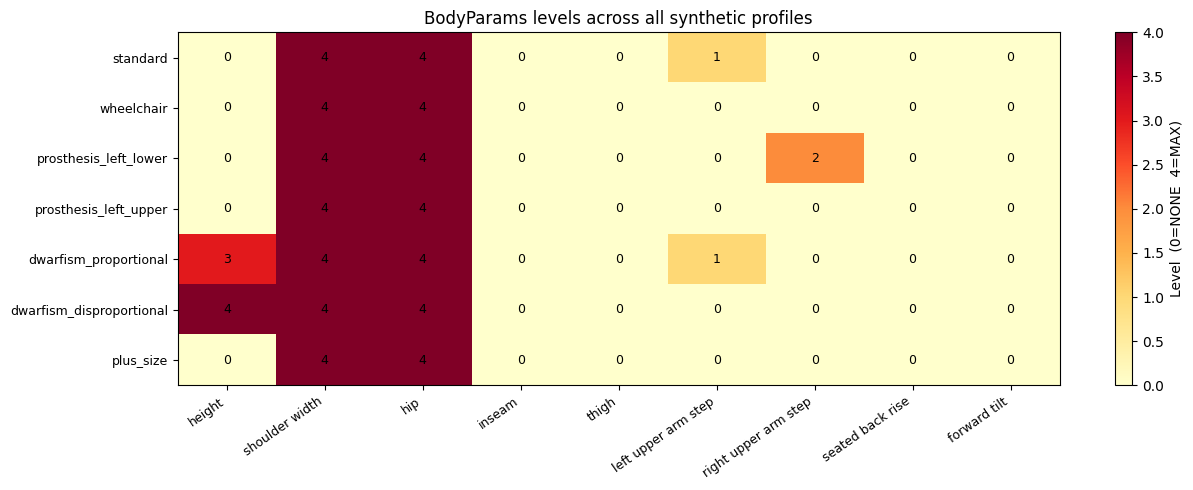

In [12]:
axes_to_show = [
    'height_level','shoulder_width_level','hip_level','inseam_level',
    'thigh_level','left_upper_arm_step','right_upper_arm_step',
    'seated_back_rise','forward_tilt_level',
]
profile_names = list(results.keys())
matrix = np.array([[getattr(results[p], ax).value for ax in axes_to_show] for p in profile_names])

fig, ax = plt.subplots(figsize=(13, 5))
im = ax.imshow(matrix, cmap='YlOrRd', vmin=0, vmax=4, aspect='auto')
ax.set_xticks(range(len(axes_to_show)))
ax.set_xticklabels([a.replace('_level','').replace('_',' ') for a in axes_to_show],
                   rotation=35, ha='right', fontsize=9)
ax.set_yticks(range(len(profile_names)))
ax.set_yticklabels(profile_names, fontsize=9)
for i in range(len(profile_names)):
    for j in range(len(axes_to_show)):
        ax.text(j, i, str(matrix[i,j]), ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=ax, label='Level  (0=NONE  4=MAX)')
ax.set_title('BodyParams levels across all synthetic profiles')
plt.tight_layout(); plt.show()

## Step 7: PointNet encoder preview (requires PyTorch)

Preview of the future `LandmarkNet` — the neural model that will replace the heuristic
landmark extraction above once training data is available.

**Architecture:**
```
(1, 3, 2048)  ->  Conv1d shared MLP (3->64->128->1024)  ->  GlobalMaxPool  ->  (1, 1024)  ->  MLP head  ->  7 measurements
```
The max-pool step is what makes PointNet permutation-invariant — the output is the same
regardless of the order of the 2048 input points.

In [13]:
try:
    import torch
    from research.models.encoder import build_encoder
    from research.models.landmark_net import LandmarkNet

    encoder = build_encoder('pointnet', feature_dim=256)
    print(encoder)

    # encoder.forward() expects (B, N, 3) — it does the transpose to (B, 3, N) internally.
    # Do NOT permute here; just add the batch dimension.
    pts_t = torch.from_numpy(pts_clean).unsqueeze(0)   # (1, 2048, 3)

    with torch.no_grad():
        features = encoder(pts_t)

    print(f'\nInput:  {tuple(pts_t.shape)}  (batch, N_points, xyz)')
    print(f'Output: {tuple(features.shape)}  (batch, global_feature_dim)')
    print(f'\nThe {features.shape[1]}-dim vector encodes global body shape.')
    print('LandmarkNet adds an MLP head to map this to 7 scalar body measurements.')

    # LandmarkNet also expects (B, N, 3)
    net = LandmarkNet(feature_dim=256)
    with torch.no_grad():
        preds = net(pts_t)
    print(f'LandmarkNet output: {tuple(preds.shape)}  (batch, 7 measurements in [0,1])')

except ImportError:
    print('PyTorch not installed — skipping encoder preview.')
    print('Install with: pip install torch')

PointNetEncoder(
  (conv1): Conv1d(3, 64, kernel_size=(1,), stride=(1,))
  (conv2): Conv1d(64, 128, kernel_size=(1,), stride=(1,))
  (conv3): Conv1d(128, 256, kernel_size=(1,), stride=(1,))
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)

Input:  (1, 2048, 3)  (batch, N_points, xyz)
Output: (1, 256)  (batch, global_feature_dim)

The 256-dim vector encodes global body shape.
LandmarkNet adds an MLP head to map this to 7 scalar body measurements.
LandmarkNet output: (1, 7)  (batch, 7 measurements in [0,1])


## Full pipeline — one block

Everything above in a single runnable cell:

In [14]:
# ── Complete pipeline in one block ───────────────────────────────────────────

# 1. Load or generate
pts_raw   = gen.generate_body(gen.PROFILES['prosthesis_left_lower'])

# 2. Preprocess  (outlier removal -> downsample -> normalise -> align)
pts_clean, _ = PreprocessPipeline(PreprocessConfig(n_points=2048))(pts_raw)

# 3. Extract heuristic landmarks from XYZ geometry
landmarks = LandmarkDetector().detect(pts_clean)

# 4. Map to discrete BodyParams levels
mapper = ScanToParams()
params = mapper.from_landmarks(
    landmarks,
    height_m=gen.PROFILES['prosthesis_left_lower'].height_m
)

# 5. Explain the scan-to-params mapping
print(mapper.explain(landmarks, params))

# 6. (If adjuster installed) adjust a pattern and export
# from diverse_body_pattern_adjuster.pattern.adjustment import PatternAdjuster
# from diverse_body_pattern_adjuster.pattern.export import export_dxf
# result = PatternAdjuster().adjust(params)
# export_dxf(result, pathlib.Path('output.dxf'))

── Scan → BodyParams Mapping Explanation ──
  shoulder_width (norm=0.743)  →  shoulder_width_level = 4
  hip_width      (norm=0.968)  →  hip_level = 4
  arm_asymmetry  (Δ=0.135)  →  left_arm=0  right_arm=2
  leg_asymmetry  (Δ=1.000)  →  left_leg=4  right_leg=0
  height_level   = 0
  inseam_level   = 0
  weight_level   = 4


### Further reading

| Resource | What it covers |
|---|---|
| `docs/ALGORITHMS.md` | Every formula with paper citations, paper comparisons, Kaggle dataset guide |
| `docs/pipeline.svg` | Two-repo pipeline diagram |
| `docs/model_architecture.svg` | LandmarkNet layer shapes |
| `docs/body_params_levels.svg` | Level 0-4 reference table |
| `research/mapping/scan_to_params.py` | Threshold definitions + explain() source |
| `research/pointcloud/landmarks.py` | All geometric heuristic formulas |

**Papers:** [PointNet](https://arxiv.org/abs/1612.00593) · [PointNet++](https://arxiv.org/abs/1706.02413) · [NeuralTailor](https://arxiv.org/abs/2201.13063) · [SewPCT](https://link.springer.com/chapter/10.1007/978-3-031-82021-2_15)